Initial Observation (State): (386, {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})
Training completed over 2000 episodes!


Average Reward over 100 test episodes: -18.76
Success Rate: 87.0%


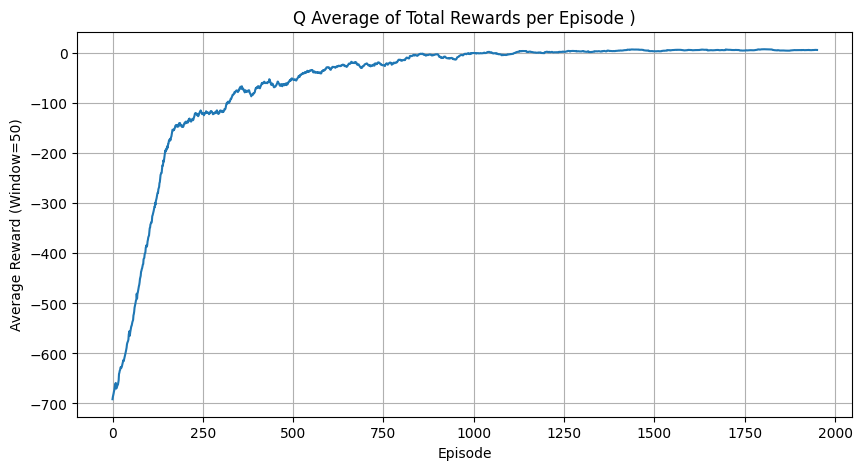

In [4]:
!pip install gymnasium
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
env = gym.make("Taxi-v3")
observation  = env.reset(seed=42)
print(f"Initial Observation (State): {observation}")


state_size = env.observation_space.n
action_size = env.action_space.n
q_table = np.zeros((state_size, action_size))

alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.005
min_epsilon = 0.01
episodes = 2000

rewards_per_episode = []


for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:

        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state, :])


        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated


        best_next_action = np.max(q_table[next_state, :])


        td = reward + (gamma * best_next_action) - q_table[state, action]


        q_table[state, action] = q_table[state, action] + (alpha * td)


        state = next_state
        total_reward += reward


    epsilon = max(min_epsilon, epsilon - epsilon_decay)
    rewards_per_episode.append(total_reward)

print(f"Training completed over {episodes} episodes!\n")
print("="*40 + "\n")

test_episodes = 100
successes = 0
total_test_rewards = 0

for _ in range(test_episodes):
    state, info = env.reset()
    done = False
    episode_reward = 0

    while not done:
        action = np.argmax(q_table[state, :])
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward

    total_test_rewards += episode_reward

    if episode_reward > 0:
        successes += 1

print(f"Average Reward over {test_episodes} test episodes: {total_test_rewards/test_episodes}")
print(f"Success Rate: {(successes/test_episodes)*100}%")

env.close()

\
def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_per_episode))
plt.title('Q Average of Total Rewards per Episode )')
plt.xlabel('Episode')
plt.ylabel('Average Reward (Window=50)')
plt.grid(True)
plt.show()
